<a href="https://colab.research.google.com/github/felipetavaressilvaoliveira-netizen/senacai/blob/main/projetov1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Baixando dataset (7.25 GB)... Isso pode levar alguns minutos.
Dataset URL: https://www.kaggle.com/datasets/soumendraprasad/musical-instruments-sound-dataset
Processando áudios de TREINO... Filtrando silêncios e arquivos vazios.

Gerando 4 Mel spectrograms de amostra por classe...


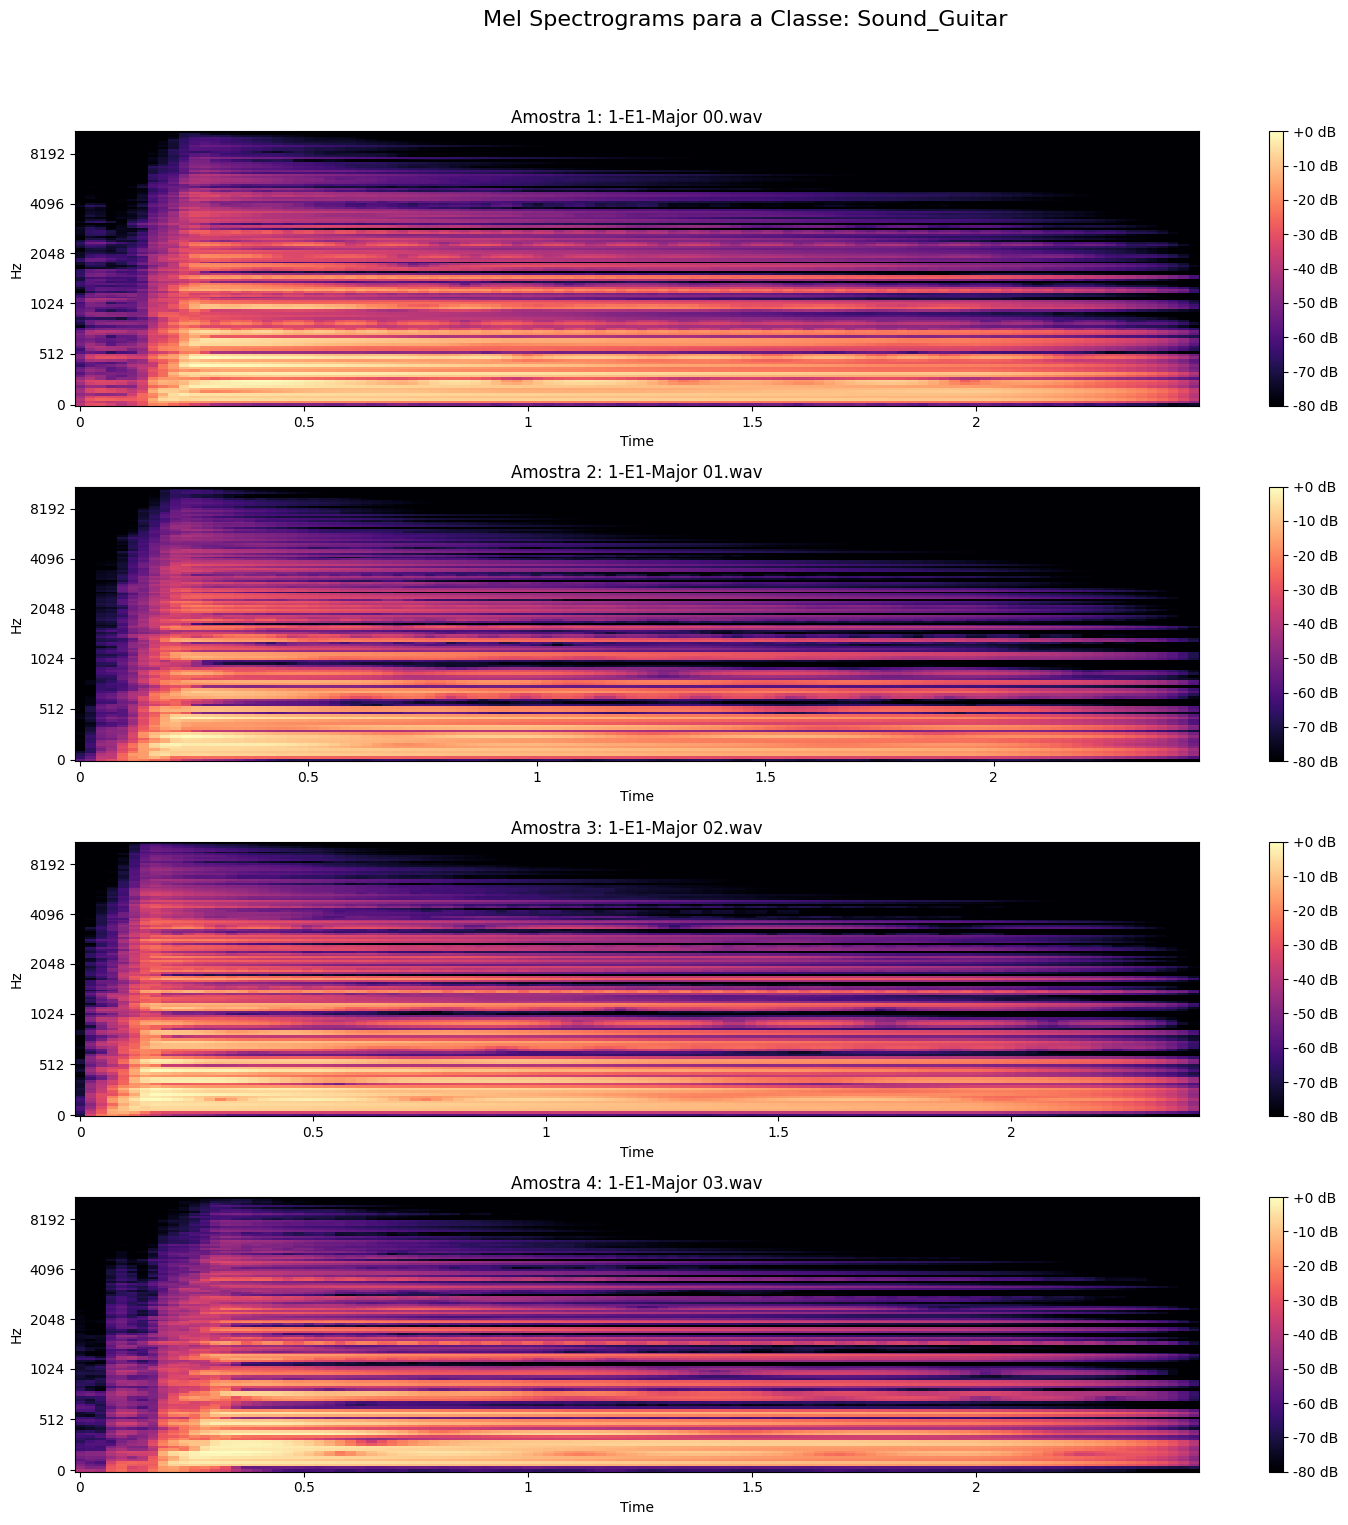

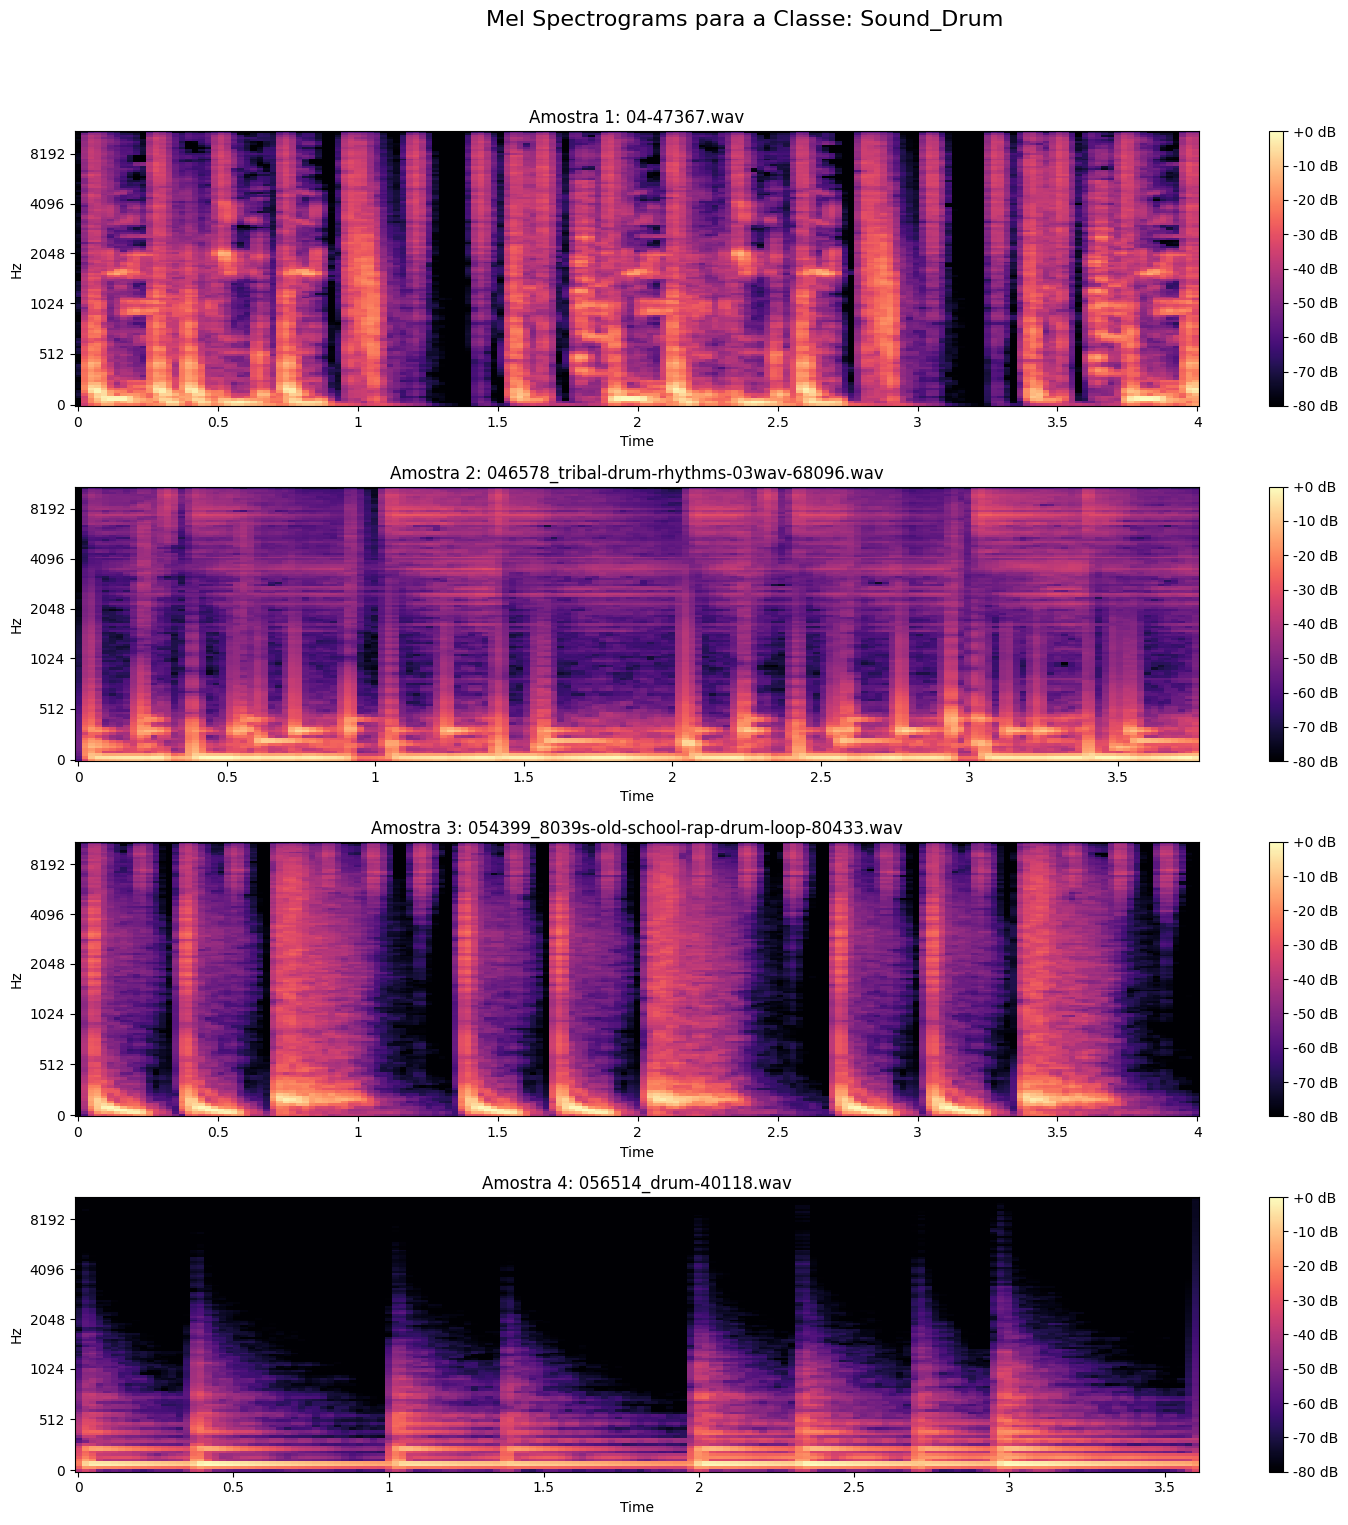

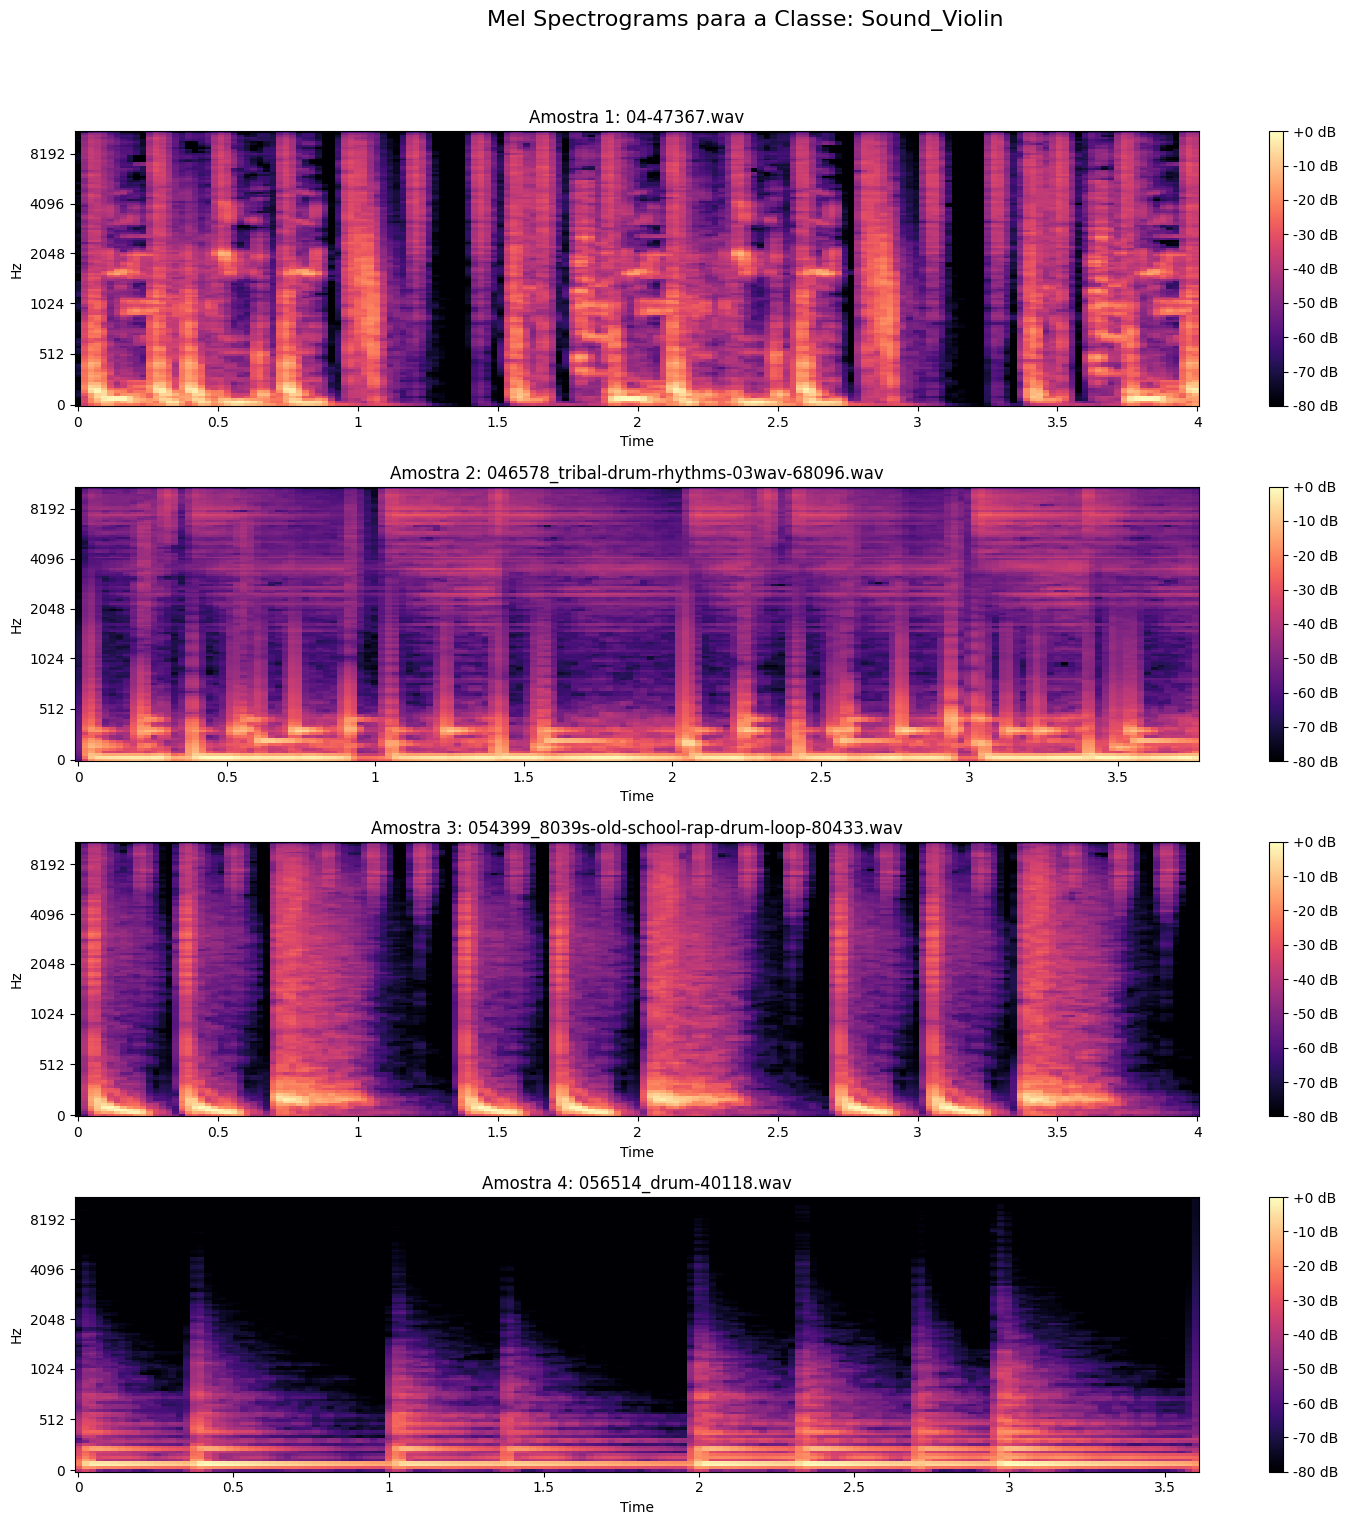

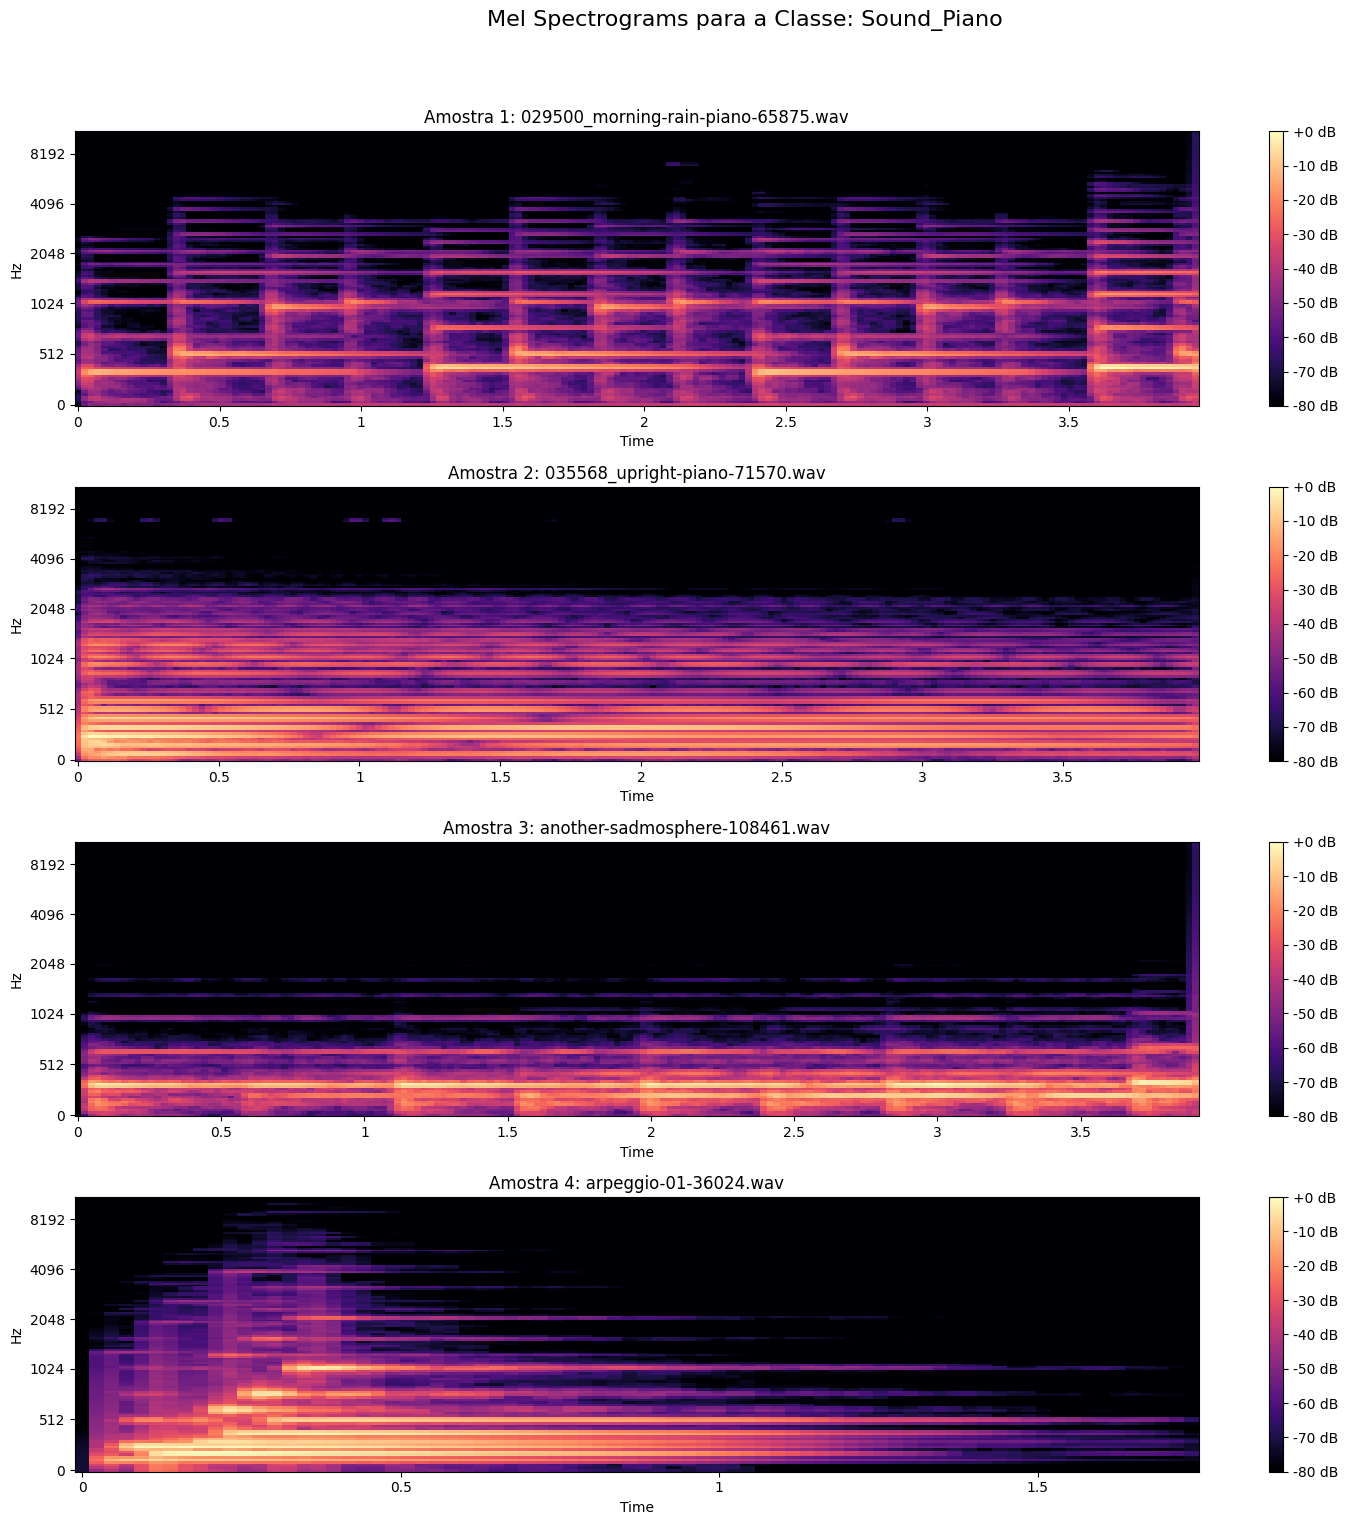

/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1160
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1672
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=648
  warnings.warn(



Processando áudios de TESTE... Filtrando silêncios e arquivos vazios.
Epoch 1/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4469 - loss: 8.7584 - val_accuracy: 0.3375 - val_loss: 28.0725
Epoch 2/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5306 - loss: 3.7141 - val_accuracy: 0.2875 - val_loss: 19.1919
Epoch 3/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5637 - loss: 2.4307 - val_accuracy: 0.5375 - val_loss: 15.7506
Epoch 4/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6097 - loss: 1.5156 - val_accuracy: 0.5250 - val_loss: 14.5256
Epoch 5/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6227 - loss: 1.2662 - val_accuracy: 0.3875 - val_loss: 14.7347
Epoch 6/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6470 - loss: 1.0106 - val_accuracy: 0.3625 - val_loss: 13.9579
Epoch 7/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6588 - loss: 0.9359 - val_accuracy: 0.4125 - val_loss: 12.6163
Epoch 8/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


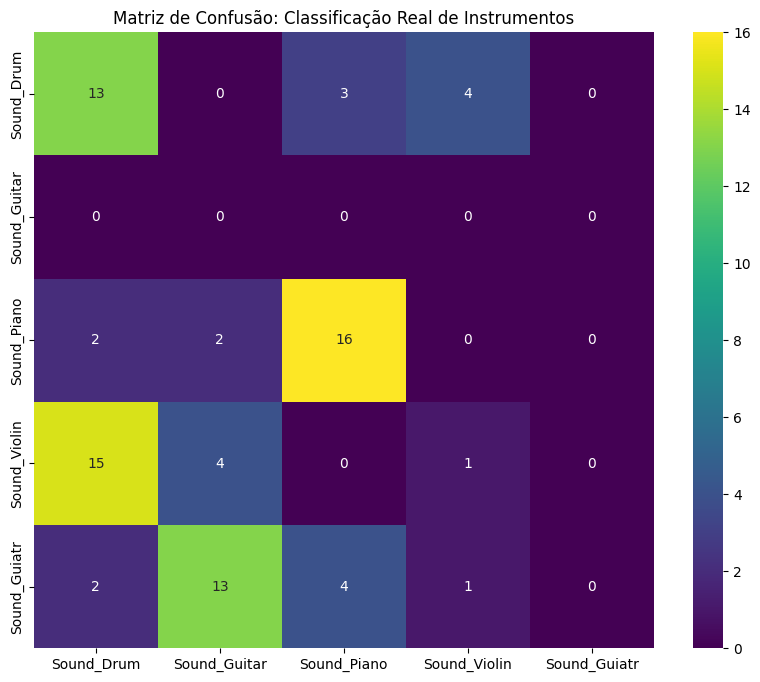

In [17]:
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from google.colab import userdata
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models

# --- 1. CONFIGURAÇÃO KAGGLE ---
os.environ['KAGGLE_KEY'] = userdata.get('API_KEY_COLAB')
os.environ['KAGGLE_USERNAME'] = "felipeoliveira12"

from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()

print("Baixando dataset (7.25 GB)... Isso pode levar alguns minutos.")
api.dataset_download_files('soumendraprasad/musical-instruments-sound-dataset', path='.', unzip=True)

# --- 2. LOCALIZAÇÃO DOS ARQUIVOS ---
# O Kaggle costuma criar subpastas. Vamos encontrar onde estão os .wav
caminho_base_train = "./Train_submission/Train_submission" # Caminho para os arquivos de treino
caminho_base_test = "./Test_submission/Test_submission" # Caminho para os arquivos de teste

# Verifica se os caminhos existem
if not os.path.exists(caminho_base_train):
    print(f"Alerta: Pasta {caminho_base_train} não encontrada. Verificando diretórios...")
    print(os.listdir('.'))
if not os.path.exists(caminho_base_test):
    print(f"Alerta: Pasta {caminho_base_test} não encontrada. Verificando diretórios...")
    print(os.listdir('.'))

# --- 3. FUNÇÕES DE LIMPEZA (REQUISITOS DO DESAFIO) ---

def processar_audio_limpo(caminho):
    try:
        # Carrega apenas os primeiros 4 segundos para economizar memória e tempo
        y, sr = librosa.load(caminho, sr=22050, duration=4.0)

        # 1. REMOVE SILÊNCIO (Início e Fim) - Aumentando top_db para ser menos agressivo
        y_trimmed, _ = librosa.effects.trim(y, top_db=60) # Valor padrão do librosa

        # 2. REMOVE ÁUDIOS SEM SOM (Se a amplitude máxima for muito baixa) - Removendo temporariamente o filtro
        # if np.max(np.abs(y_trimmed)) < 0.01:
        #     return None, None

        return y_trimmed, sr
    except Exception as e: # Adicionando print para depuração de erros de carregamento
        print(f"Erro ao processar áudio {caminho}: {e}") # Descomentar esta linha
        return None, None

def plot_sample_spectrograms(df_metadata, base_path, audio_processor, num_samples=4):
    print(f"\nGerando {num_samples} Mel spectrograms de amostra por classe...")
    unique_classes = df_metadata['Class'].unique()

    for class_name in unique_classes:
        class_samples = df_metadata[df_metadata['Class'] == class_name].head(num_samples)

        plt.figure(figsize=(15, 4 * num_samples)) # Adjust figure size dynamically
        plt.suptitle(f'Mel Spectrograms para a Classe: {class_name}', fontsize=16)

        for i, (index, row) in enumerate(class_samples.iterrows()):
            file_name = row['FileName']
            full_path = os.path.join(base_path, file_name)

            # Adiciona verificação de existência do arquivo antes de tentar processá-lo
            if not os.path.exists(full_path):
                print(f"Arquivo de spectrogram não encontrado: {full_path}")
                continue

            audio, sr = audio_processor(full_path)
            if audio is not None:
                plt.subplot(num_samples, 1, i + 1) # num_samples rows, 1 col
                S = librosa.feature.melspectrogram(y=audio, sr=sr)
                S_db = librosa.power_to_db(S, ref=np.max)
                librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel')
                plt.colorbar(format='%+2.0f dB')
                plt.title(f'Amostra {i+1}: {file_name}')
            else:
                print(f"Não foi possível processar o áudio para spectrogram: {file_name}")
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
        plt.show()

# --- 4. PROCESSAMENTO E EXTRAÇÃO ---

# Processamento dos dados de TREINO
df_train_meta = pd.read_csv('Metadata_Train.csv')

# --- Incorpora novos áudios de violino do Pixabay, se houver ---
new_metadata_path = 'Pixabay_Violin_Metadata.csv'
if os.path.exists(new_metadata_path):
    print(f"Incorporando metadados de novos áudios de violino de '{new_metadata_path}'...")
    df_pixabay_violin = pd.read_csv(new_metadata_path)
    df_train_meta = pd.concat([df_train_meta, df_pixabay_violin], ignore_index=True)

X_train_features, y_train_labels = [], []

print("Processando áudios de TREINO... Filtrando silêncios e arquivos vazios.")
# Chama a função para plotar spectrograms de amostra do conjunto de treino
plot_sample_spectrograms(df_train_meta, caminho_base_train, processar_audio_limpo, num_samples=4)

# Limitando arquivos para não estourar a RAM do Colab. Remova o [:N] para processar tudo.
for index, row in df_train_meta.iterrows(): #.head(1000): # Exemplo de limite
    caminho_arquivo = os.path.join(caminho_base_train, row['FileName'])

    # Adiciona verificação de existência do arquivo antes de tentar processá-lo
    if not os.path.exists(caminho_arquivo):
        print(f"Arquivo de treino não encontrado: {caminho_arquivo}")
        continue

    if os.path.exists(caminho_arquivo):
        audio, sr = processar_audio_limpo(caminho_arquivo)
        if audio is not None:
            mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
            if mfccs.shape[1] > 0: # Adicionado: Garante que MFCCs não estão vazios
                X_train_features.append(np.mean(mfccs.T, axis=0))
                y_train_labels.append(row['Class'])

# Processamento dos dados de TESTE
df_test_meta = pd.read_csv('Metadata_Test.csv')
X_test_features, y_test_labels = [], []

print("\nProcessando áudios de TESTE... Filtrando silêncios e arquivos vazios.")
# Limitando arquivos para não estourar a RAM do Colab. Remova o [:N] para processar tudo.
for index, row in df_test_meta.iterrows(): #.head(1000): # Exemplo de limite
    caminho_arquivo = os.path.join(caminho_base_test, row['FileName'])

    # Adiciona verificação de existência do arquivo antes de tentar processá-lo
    if not os.path.exists(caminho_arquivo):
        print(f"Arquivo de teste não encontrado: {caminho_arquivo}")
        continue

    if os.path.exists(caminho_arquivo):
        audio, sr = processar_audio_limpo(caminho_arquivo)
        if audio is not None:
            mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
            if mfccs.shape[1] > 0: # Adicionado: Garante que MFCCs não estão vazios
                X_test_features.append(np.mean(mfccs.T, axis=0))
                y_test_labels.append(row['Class'])


X_train = np.array(X_train_features)
y_train_raw = pd.get_dummies(y_train_labels) # Usar o raw para mapear as classes mais tarde
X_test = np.array(X_test_features)
y_test_raw = pd.get_dummies(y_test_labels) # Usar o raw para mapear as classes mais tarde

# Garante que todas as classes estejam representadas em ambos os conjuntos (treino e teste)
all_classes = pd.concat([y_train_raw, y_test_raw]).columns.unique()
y_train = y_train_raw.reindex(columns=all_classes, fill_value=0).values.astype(float) # Convertendo para float
y_test = y_test_raw.reindex(columns=all_classes, fill_value=0).values.astype(float)   # Convertendo para float
classes = all_classes # Atualiza a variável classes

# --- 5. MODELO E RESULTADOS ---

# Remove o train_test_split, pois os dados já estão separados
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Verifica se há dados nos conjuntos de treino e teste
if len(X_train) > 0 and len(X_test) > 0:
    model = models.Sequential([
        layers.Input(shape=(40,)),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dense(len(classes), activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), verbose=1)

    # --- 6. VISUALIZAÇÃO DA MATRIZ DE CONFUSÃO ---
    y_pred = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(y_test, axis=1)

    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d',
                xticklabels=classes, yticklabels=classes, cmap='viridis')
    plt.title('Matriz de Confusão: Classificação Real de Instrumentos')
    plt.show()
else:
    print("Nenhum áudio válido foi processado para treinamento ou teste. Verifique os caminhos dos arquivos e as condições de filtragem.")

### 7. Testando o Modelo com um Novo Áudio da Internet

Vamos baixar um arquivo de áudio da internet, processá-lo e usar o modelo treinado para prever o tipo de instrumento.

In [18]:
# Instalação das bibliotecas necessárias para converter MP3 para WAV
!pip install pydub
!apt-get update
!apt-get install -y ffmpeg
print("pydub e ffmpeg instalados com sucesso.")

import requests
import os
import pandas as pd
import time # Para adicionar um pequeno atraso entre os downloads

print("Preparando para baixar áudios de violino do Pixabay...")

# --- ATENÇÃO: As URLs abaixo são exemplos/placeholders. ---
# Você precisará inspecionar a página do Pixabay (ou as páginas individuais dos sons)
# para obter os links de download diretos para os arquivos WAV.
# URLs de download diretas de arquivos WAV do Pixabay são geralmente no formato:
# https://cdn.pixabay.com/download/audio/<ano>/<mes>/<dia>/<id_e_nome_do_arquivo>.wav
# Por exemplo, para um som de violino, pode ser algo como:
# https://cdn.pixabay.com/download/audio/2024/02/08/violin-melody-12345.wav
# A coleta automática desses links de download diretos é complexa e pode ser instável
# devido a mudanças na estrutura do site. Recomenda-se coletar os 20 primeiros links manualmente.

# Placeholder URLs - por favor, substitua por URLs reais de arquivos WAV de violino do Pixabay
pixabay_violin_urls = [
    "https://example.com/violin_placeholder_01.wav",
    "https://example.com/violin_placeholder_02.wav",
    "https://example.com/violin_placeholder_03.wav",
    "https://example.com/violin_placeholder_04.wav",
    "https://example.com/violin_placeholder_05.wav",
    "https://example.com/violin_placeholder_06.wav",
    "https://example.com/violin_placeholder_07.wav",
    "https://example.com/violin_placeholder_08.wav",
    "https://example.com/violin_placeholder_09.wav",
    "https://example.com/violin_placeholder_10.wav",
    "https://example.com/violin_placeholder_11.wav",
    "https://example.com/violin_placeholder_12.wav",
    "https://example.com/violin_placeholder_13.wav",
    "https://example.com/violin_placeholder_14.wav",
    "https://example.com/violin_placeholder_15.wav",
    "https://example.com/violin_placeholder_16.wav",
    "https://example.com/violin_placeholder_17.wav",
    "https://example.com/violin_placeholder_18.wav",
    "https://example.com/violin_placeholder_19.wav",
    "https://example.com/violin_placeholder_20.wav"
]

download_dir = "./Train_submission/Train_submission" # Existing training directory
new_violin_metadata = []
downloaded_files_count = 0

if not os.path.exists(download_dir):
    os.makedirs(download_dir)

for i, file_url in enumerate(pixabay_violin_urls):
    if downloaded_files_count >= 20:
        break

    if "example.com" in file_url: # Pular URLs placeholder
        print(f"Pulando URL placeholder: {file_url}")
        continue

    # Extrair nome do arquivo da URL (assumindo formato de URL válido)
    try:
        file_name = os.path.basename(file_url.split('?')[0])
        # Garantir nome único para evitar sobrescrever arquivos existentes ou outros arquivos baixados
        unique_file_name = f"pixabay_violin_{i:02d}_{file_name}"
        save_path = os.path.join(download_dir, unique_file_name)

        print(f"Downloading {unique_file_name} from {file_url}...")
        file_response = requests.get(file_url, stream=True, timeout=10) # Adicionar timeout
        file_response.raise_for_status() # Levantar um HTTPError para respostas ruins (4xx ou 5xx)

        with open(save_path, 'wb') as f:
            for chunk in file_response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Downloaded: {unique_file_name}")
        new_violin_metadata.append({'FileName': unique_file_name, 'Class': 'Sound_Violin'})
        downloaded_files_count += 1
        time.sleep(1) # Ser educado, adicionar um pequeno atraso entre as requisições

    except requests.exceptions.RequestException as e:
        print(f"Erro de rede ou HTTP ao baixar '{file_url}': {e}")
    except Exception as e:
        print(f"Ocorreu um erro inesperado ao baixar '{file_url}': {e}")

if downloaded_files_count == 0:
    print("Nenhum arquivo de violino válido foi baixado. Certifique-se de que as URLs são diretas e corretas.")
else:
    print(f"Total de {downloaded_files_count} arquivos de violino baixados do Pixabay e adicionados à pasta de treino.")

# Salvar novos metadados em um CSV temporário
new_metadata_df = pd.DataFrame(new_violin_metadata)
if not new_metadata_df.empty:
    new_metadata_path = 'Pixabay_Violin_Metadata.csv'
    new_metadata_df.to_csv(new_metadata_path, index=False)
    print(f"Metadados dos novos arquivos salvos em '{new_metadata_path}'. Este arquivo será lido na próxima etapa de treinamento.")
else:
    print("Nenhum novo metadado de violino gerado para o treinamento.")

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed

In [16]:
import os
from pydub import AudioSegment # Certifique-se de que pydub está importado

# --- Configurações para o novo áudio ---
# O caminho para o seu arquivo de áudio local no Colab.
caminho_audio_local = "/content/soulfuljamtracks-classical-violin-music-478144.mp3"
nome_arquivo_para_processar = caminho_audio_local # Inicialmente, usamos o caminho original

# Variável para rastrear se um arquivo temporário foi criado
arquivo_temporario_criado = False

# --- 1. Verificar e converter (se for MP3) ---
print(f"Verificando áudio local: {caminho_audio_local}...")

if not os.path.exists(caminho_audio_local):
    print(f"Erro: Arquivo não encontrado em {caminho_audio_local}. Por favor, verifique o caminho.")
    nome_arquivo_para_processar = None # Indica que não há arquivo válido para processar
else:
    if caminho_audio_local.lower().endswith('.mp3'):
        print("Arquivo é um MP3. Tentando converter para WAV para processamento...")
        try:
            nome_arquivo_wav_temp = caminho_audio_local.replace('.mp3', '_temp.wav')
            audio_mp3 = AudioSegment.from_mp3(caminho_audio_local)
            audio_mp3.export(nome_arquivo_wav_temp, format="wav")
            print(f"Conversão de MP3 para WAV concluída. Usando: {nome_arquivo_wav_temp}")
            nome_arquivo_para_processar = nome_arquivo_wav_temp # Atualiza para o caminho do WAV temporário
            arquivo_temporario_criado = True
        except Exception as conv_e:
            print(f"Erro na conversão de MP3 para WAV: {conv_e}. Certifique-se de que `ffmpeg` está instalado.")
            nome_arquivo_para_processar = None
    elif not caminho_audio_local.lower().endswith(('.wav', '.flac')):
        print(f"Alerta: O arquivo {caminho_audio_local} não é um tipo de áudio comum (MP3, WAV, FLAC). Librosa pode ter problemas.")

if nome_arquivo_para_processar and os.path.exists(nome_arquivo_para_processar):
    # --- 2. Processar o áudio e extrair MFCCs ---
    print(f"Processando o áudio: {nome_arquivo_para_processar}")
    audio_processado, sr_processado = processar_audio_limpo(nome_arquivo_para_processar)

    if audio_processado is not None and len(audio_processado) > 0:
        mfccs_novo_audio = librosa.feature.mfcc(y=audio_processado, sr=sr_processado, n_mfcc=40)

        # --- Extração de features adicionais ---
        # Spectral Centroid
        cent_novo_audio = librosa.feature.spectral_centroid(y=audio_processado, sr=sr_processado)
        # Chroma Frequencies
        chroma_novo_audio = librosa.feature.chroma_stft(y=audio_processado, sr=sr_processado)

        if mfccs_novo_audio.shape[1] > 0:
            features_novo_audio = np.mean(mfccs_novo_audio.T, axis=0)

            # --- Imprimir features adicionais para análise ---
            print("\n--- Features Adicionais ---")
            print(f"Média do Centroide Espectral: {np.mean(cent_novo_audio):.2f}")
            print(f"Média das Features de Croma (12 valores): {np.mean(chroma_novo_audio, axis=1)}")
            print("---------------------------")

            # --- 3. Fazer a predição ---
            features_para_modelo = np.array([features_novo_audio])

            if features_para_modelo.shape[1] != 40:
                print(f"Erro: As características extraídas têm forma {features_para_modelo.shape[1]}, mas o modelo espera 40.")
            else:
                predicoes = model.predict(features_para_modelo)
                indice_predito = np.argmax(predicoes[0])
                confianca = predicoes[0][indice_predito] * 100

                if isinstance(classes, pd.Index):
                    classe_predita = classes[indice_predito]
                elif isinstance(classes, np.ndarray):
                    classe_predita = classes[indice_predito]
                else:
                    print("Erro: Formato inesperado para a variável 'classes'.")
                    classe_predita = "Desconhecida"

                # --- 4. Exibir o resultado ---
                print(f"\nO modelo previu que o áudio é de: {classe_predita} (Confiança: {confianca:.2f}%) ")

                # Opcional: Remover o arquivo WAV temporário, se foi criado
                if arquivo_temporario_criado and os.path.exists(nome_arquivo_para_processar):
                    os.remove(nome_arquivo_para_processar)
                    print(f"Arquivo temporário {nome_arquivo_para_processar} removido.")
        else:
            print("Não foi possível extrair MFCCs válidos do áudio.")
    else:
        print("Não foi possível processar o áudio (pode estar muito curto ou sem som). ")
else:
    print("Não foi possível preparar o arquivo de áudio para teste.")

Verificando áudio local: /content/soulfuljamtracks-classical-violin-music-478144.mp3...
Arquivo é um MP3. Tentando converter para WAV para processamento...
Conversão de MP3 para WAV concluída. Usando: /content/soulfuljamtracks-classical-violin-music-478144_temp.wav
Processando o áudio: /content/soulfuljamtracks-classical-violin-music-478144_temp.wav

--- Features Adicionais ---
Média do Centroide Espectral: 2115.72
Média das Features de Croma (12 valores): [0.45160204 0.3794769  0.6044988  0.23247133 0.12240651 0.20122238
 0.08992636 0.10722278 0.08873557 0.16852804 0.11689486 0.14881365]
---------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

O modelo previu que o áudio é de: Sound_Piano (Confiança: 78.97%) 
Arquivo temporário /content/soulfuljamtracks-classical-violin-music-478144_temp.wav removido.
